<a href="https://colab.research.google.com/github/sujal003-hue/Upgrade-Capstone-Project/blob/main/Google_search_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

**Installing the Pytrends**

In [4]:
!pip install pytrends

  Using cached pytrends-4.9.2-py3-none-any.whl.metadata (13 kB)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# **Setup of Pytrend Library And Keyword Defines**

In [7]:
pytrends = TrendReq(hl = 'en-US', tz = 360)
keyword = 'cloud computing'

**Note:- The result can be change only by changing the keyword.
Example:- keyword = 'artifical intelligence' or keyword = 'machine learning'**

# **Data Request**

In [14]:
pytrends.build_payload([keyword], cat = 0, timeframe= 'today 5-y', geo='', gprop ='')

# **Country Wise Interest**

In [11]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending = False).head(15)

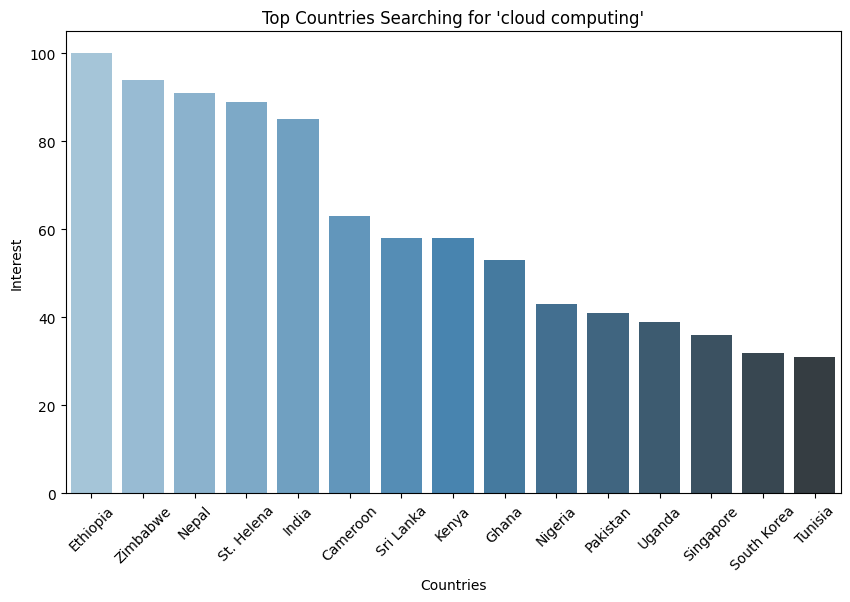

In [17]:
plt.figure(figsize = (10,6))
sns.barplot(x = region_data.index, y = region_data[keyword], palette = "Blues_d", hue = region_data.index, legend=False)
plt.title(f"Top Countries Searching for '{keyword}'")
plt.xlabel("Countries")
plt.ylabel("Interest")
plt.xticks(rotation=45)
plt.show()

# **World Map**

In [19]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations='geoName',
                    locationmode= 'country names',
                    color=keyword,
                    title=f"Search Interest for '{keyword}' by Country",
                    color_continuous_scale='Blues')
fig.show()

# **Time Wise Interest**

In [ ]:
time_df = pytrends.interest_over_timer()

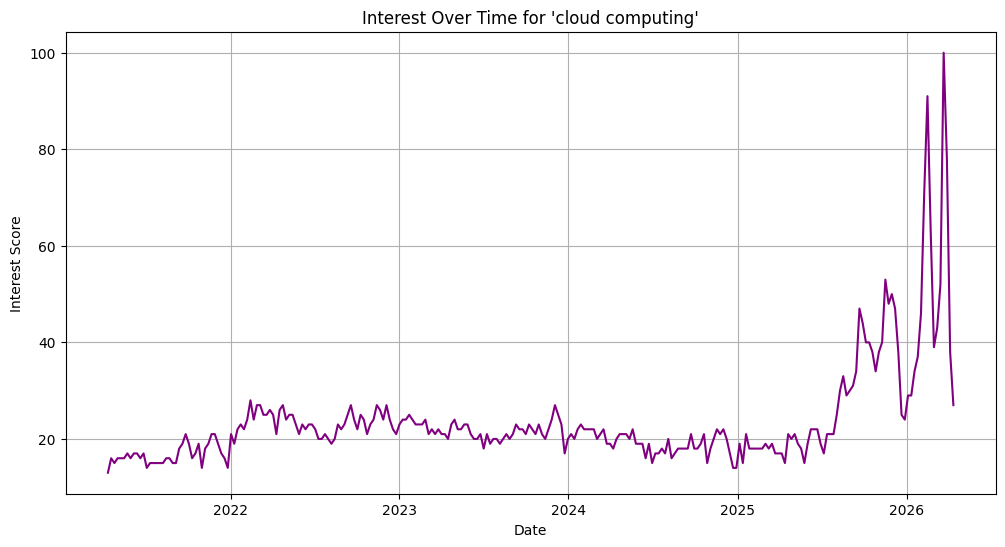

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=time_df.index, y=time_df[keyword], color = 'purple')
plt.title(f"Interest Over Time for '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.grid(True)
plt.show()

# **Multiple Key Comparison**

In [27]:
kw_list = ["cloud computing", "data science", "machine learning"]
pytrends.build_payload(kw_list, cat = 0, timeframe = 'today 5-y', geo ='', gprop='')

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



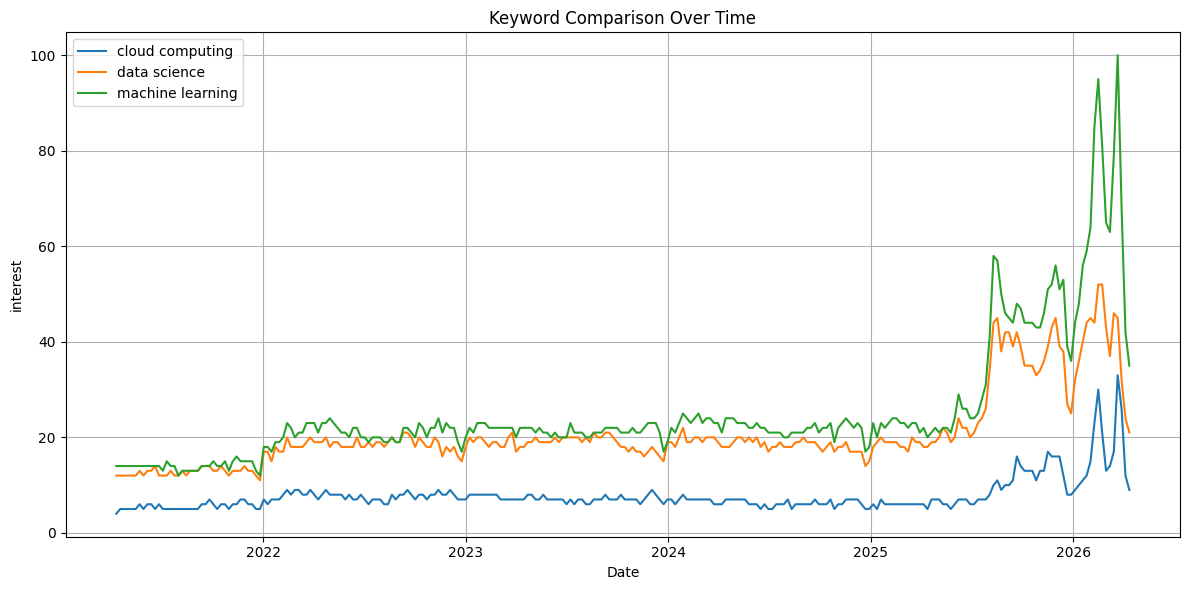

In [31]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label = kw)

plt.title("Keyword Comparison Over Time")
plt.xlabel("Date")
plt.ylabel("interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Conclusion**

**To conclude by saying that in this firstly we install pytrend, then load our dataset from pytrends library. We have perform various analysis in our dataset through bargraph, barplot and also made a comparison of a country from whole word. In this dataset we made a comparison of country wise interest, time wise interest in whole world.**